# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Camello, Zack Kenshin)_: 
- _Student No._: 2024-08825
- _Section_: THR-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure
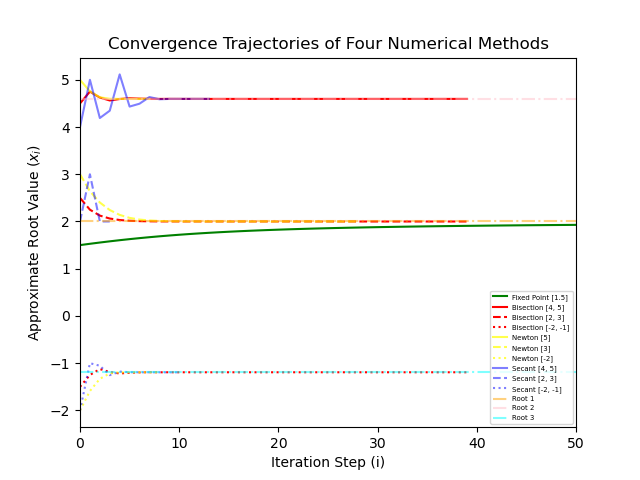

### Report discussion
1. Explain the report figure.

The report figure simply displays the differing speeds of convergence for all four root-finding methods given their initial guesses and bounds. Interesting points to note for each method: The Fixed-Point method displayed a slow and steady convergence, both Secant and Newton methods converge within only a few iterations, while Bisection method reaches its tolerance within a predictable amount of iterations.

2. What are the advantages and disadvantages of the root-finding methods?

Fixed-point Method:
- Advantages: Simple to implement formula and steadily obtains the root value.
- Disadvatages: Exponentially slows down the closer it is to the root value and FAILS when roots have extremely steep slopes ($g'(x) > 1$).

Bisection Method:
- Advantages: Moderately fast at finding the root value and converges at a predictable iteration count
- Disadvantages: Requires bounds that are ensured to have a root, otherwise will fail. Additionally, if the function crosses an even amount of times within the interval, the boundary signs will be the same, causing the method to fail.

Newton Method:
- Advantages: Only requires one guess and converges extremely quickly
- Disadvantages: Requires both the function and its derivative to be coded and fails whenever the derivative evaluates to 0 (or near 0).

Secant Method: 
- Advantages: Extremely fast to converge overall and only requires the original function and 2 initial guesses
- Disadvantages: Extremely unstable during the first iterations and thus not always consistently fast in converging. The method can also fail when given bad boundaries (such as no root within the boundary). 

### Other comments

---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

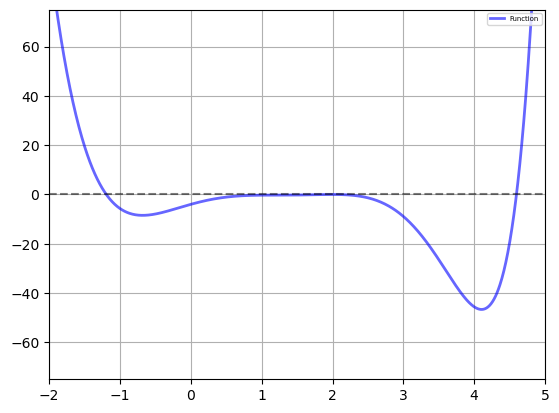

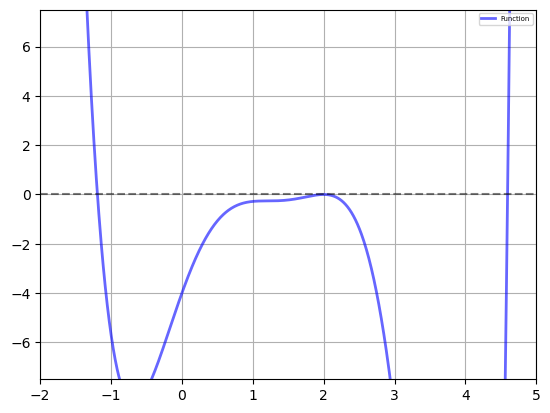

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = 10000 # Max Iteration Count
x_axis = np.linspace(-2, 5, 1000)

# Original Function
def base_func(x):
    return (-(x ** 5) + (4 * (x ** 4)) - (4 * (x ** 3)) + ((x ** 2)*(np.e ** x)) - 
            (2 * (x ** 2)) - (4 * x * (np.e ** x)) + (8 * x) + (4 * (np.e ** x)) - 8)

# Manipulated function in the form x = g(x)
def fixed_function(x):
    return ((1/8) * ((x ** 5) - (4 * (x ** 4)) + (4 * (x ** 3)) - ((x ** 2)*(np.e ** x)) + (2 * (x ** 2)) + 
                (4 * x * (np.e ** x)) - (4 * (np.e ** x)) + 8))

# Derivative of Original function
def derivative(x): 
    return ((-5 * (x ** 4)) + (16 * (x ** 3)) + (-12 * (x ** 2)) + - (4 * x) + 8 - (2 * x * (np.e ** x)) + ((x ** 2) * (np.e ** x)))

def fixed_point_method(guess, tolerance):
    roots = [guess] # Puts our initial guess in here and is appended each iteration
    
    for i in range(N): 
        x_next = fixed_function(roots[-1]) # Puts in the most recent root into our fixed function
        roots.append(x_next) # Appends current x value into our array of roots
        
        if abs(roots[-1] - roots[-2]) < tolerance: # Stops the calculations once some tolerance is reached
            return roots
    return roots

def bisection_method(guess1, guess2, tolerance):
    roots = []

    for i in range(N):
        midpoint = (guess1 + guess2)/2 # The root is the midpoint between 2 bounds that were sure a root is present
        roots.append(midpoint)

        if base_func(guess1) * base_func(midpoint) < 0: # Checks whether the midpoint is between guess1 and current midpoint or guess2 and current midpoint then overwrites the other value to the value of the midpoint
            guess2 = midpoint
        else:
            guess1 = midpoint

        if (guess2 - guess1) < tolerance:
            return roots

def newton_method(guess, tolerance):
    roots = [guess] # Puts our initial guess in here and is built upon through each iteration

    for i in range(N):
        x_next = roots[-1] - (base_func(roots[-1]) / derivative(roots[-1])) # Newton Method Formula in calculating the next x value
        roots.append(x_next)

        if abs(roots[-1] - roots[-2]) < tolerance:
            return roots

def secant_method(guess1, guess2, tolerance):
    roots = [guess1, guess2] # Places our initial guesses in here and is built upon through each iteration

    for i in range(N):
        x_prev, x_cur = roots[-2], roots[-1] # x_{n-1} and x_n are simply the last and 2nd to the last entries in the array
        f_prev, f_cur = base_func(x_prev), base_func(x_cur) # Corresponding function value of the 2 x values
        
        x_next = x_cur - (f_cur * ((x_cur - x_prev)/(f_cur - f_prev))) # Secant Method Formula
        roots.append(x_next)

        if abs(roots[-1] - roots[-2]) < tolerance:
            return roots
            
# Base Function
plt.figure()
plt.plot(x_axis, base_func(x_axis), color="blue", linewidth=2, label="Function", alpha=0.60) # Plots the Base Function
plt.axhline(y=0, color="black", linestyle='--', alpha = 0.5) # Reference Line
plt.legend(fontsize=5, loc = "upper right")
plt.xlim(-2,5)
plt.ylim(-75, 75)
plt.grid()
plt.savefig("Base Function")
plt.show()

# Zoomed in version of Base Function
plt.figure()
plt.plot(x_axis, base_func(x_axis), color='blue', linewidth=2, label="Function", alpha=0.60)
plt.axhline(y=0, color="black", linestyle='--', alpha = 0.5)
plt.legend(fontsize=5, loc = "upper right")
plt.xlim(-2,5)
plt.ylim(-7.5, 7.5)
plt.grid()
plt.savefig("Zoomed Base Function")
plt.show()

Fixed Point Method Roots:  1.9996926242194024
Bisection Method Roots:  4.595863564923093 2.0000000256104613 -1.192685765022361
Newton Method Roots:  4.595863564922456 2.0000000214246434 -1.1926857650225988
Secant Method Roots:  4.595863564922453 2.0000000000000004 -1.1926857650225988


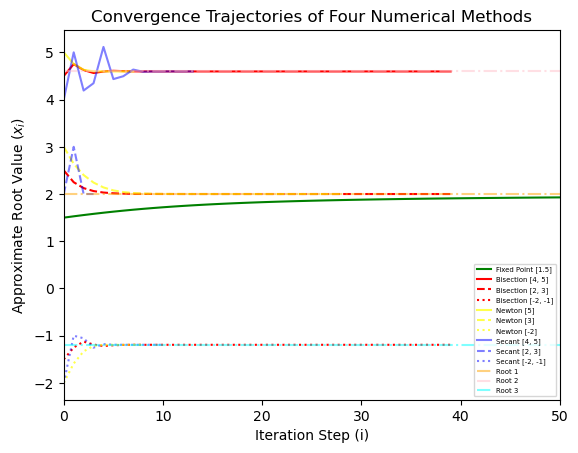

In [3]:
# Fixed Point Method
fixed_root1 = fixed_point_method(1.5, 1e-12)
# fixed_root2 = fixed_point_method(4.5, 1e-10) Fails due to high slope
print("Fixed Point Method Roots: ", fixed_root1[-1])

# Bisection Method
bisect_root1 = bisection_method(4, 5, 1e-12)
bisect_root2 = bisection_method(2, 3, 1e-12)
bisect_root3 = bisection_method(-2, -1, 1e-12)
print("Bisection Method Roots: ", bisect_root1[-1], bisect_root2[-1], bisect_root3[-1])

# Newton Method
newton_root1 = newton_method(5, 1e-12)
newton_root2 = newton_method(3, 1e-12)
newton_root3 = newton_method(-2, 1e-12)
print("Newton Method Roots: ", newton_root1[-1], newton_root2[-1], newton_root3[-1])

# Secant Method
secant_root1 = secant_method(4, 5, 1e-12)
secant_root2 = secant_method(2, 3, 1e-12)
secant_root3 = secant_method(-2, -1, 1e-12)
print("Secant Method Roots: ", secant_root1[-1], secant_root2[-1], secant_root3[-1])

# Plotted roots through iteration
plt.figure()

# Experimental Roots
plt.plot(np.arange(len(fixed_root1)), fixed_root1, label = "Fixed Point [1.5]", color = "green")
plt.plot(np.arange(len(bisect_root1)), bisect_root1, label = "Bisection [4, 5]", color = "red")
plt.plot(np.arange(len(bisect_root2)), bisect_root2, label = "Bisection [2, 3]", color = "red", linestyle="--")
plt.plot(np.arange(len(bisect_root3)), bisect_root3, label = "Bisection [-2, -1]", color = "red", linestyle=":")
plt.plot(np.arange(len(newton_root1)), newton_root1, label = "Newton [5]", color = "yellow", alpha = 0.7)
plt.plot(np.arange(len(newton_root2)), newton_root2, label = "Newton [3]", color = "yellow", alpha = 0.7, linestyle="--")
plt.plot(np.arange(len(newton_root3)), newton_root3, label = "Newton [-2]", color = "yellow", alpha = 0.7, linestyle=":")
plt.plot(np.arange(len(secant_root1)), secant_root1, label = "Secant [4, 5]", color = "blue", alpha = 0.5)
plt.plot(np.arange(len(secant_root2)), secant_root2, label = "Secant [2, 3]", color = "blue", alpha = 0.5, linestyle="--")
plt.plot(np.arange(len(secant_root3)), secant_root3, label = "Secant [-2, -1]", color = "blue", alpha = 0.5, linestyle=":")

# Theoretical Approximate Roots
plt.axhline(y=2, color="orange", linestyle='-.', alpha = 0.5, label = "Root 1")
plt.axhline(y=4.5959, color="pink", linestyle='-.', alpha = 0.5, label = "Root 2")
plt.axhline(y=-1.1927, color="cyan", linestyle='-.', alpha = 0.5, label = "Root 3")

plt.xlim(0, 50) # To limit x axis for visualization
plt.title("Convergence Trajectories of Four Numerical Methods")
plt.xlabel(f"Iteration Step (i)")
plt.ylabel(f"Approximate Root Value ($x_i$)")
plt.legend(fontsize=5, loc = "lower right")
plt.savefig("Roots per Method through time")
plt.show()